# The volatility-regime momentum model

This notebook defines the house pricing model we use for continuous up/down snap contracts, explains
each design choice step by step, and backtests it.

**The idea in one line.** Every second we must quote decimal odds on "will the price be higher in
`horizon` seconds?". The model estimates the probability of an up move from the recent **momentum**,
but calibrated separately for each **volatility regime**, because the same momentum means very
different things in a calm market versus a turbulent one.

All the plumbing (data, features, pricing, the book engine, the bettor strategies) lives in
`helper.py`; the model itself is built here, in the open. Some design choices below are annotated
with the internal study that validated them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import helper

parameters = helper.MarketParameters()
prices = helper.load_prices()
features = helper.build_features(prices, parameters)

entries = helper.contract_entries(features.number_of_seconds, parameters)
outcomes = helper.contract_outcomes(features, entries, parameters)
momentum = features.standardized_momentum
volatility = features.annualized_volatility

print(f"{features.number_of_seconds:,} seconds (~{features.number_of_seconds/86_400:.0f} days), "
      f"{len(entries):,} non-overlapping contracts")
print(f"horizon = {parameters.horizon_seconds}s, momentum lookback = {parameters.momentum_lookback_seconds}s, "
      f"house margin (vig) = {parameters.house_margin:.1%}")

Matplotlib is building the font cache; this may take a moment.


16,473,672 seconds (~191 days), 549,102 non-overlapping contracts
horizon = 30s, momentum lookback = 5s, house margin (vig) = 12.5%


## Design choices at a glance

- **Signal = standardized momentum.** The trailing log-return over `momentum_lookback` seconds,
  divided by the local volatility, so the signal is comparable across time.
- **Condition on the volatility regime (3 terciles).** A single momentum curve is mispriced inside
  volatility regimes; an internal attack study found a profitable pocket in low-volatility,
  extreme-momentum contracts. Conditioning on volatility removes it: against an internal regime-aware
  attacker, adding this dimension cut its edge from about **+4.7% to about +3.0%** while slightly
  raising the house edge. We use 3 regimes because more regimes means less data per cell.
- **Shrink each calibrated curve toward 0.5 by 40%.** We keep 40% of each bin's estimated edge. An
  internal sweep of 0.40 vs 0.70 found that 0.70 cuts the informed edge by only ~70 basis points but
  drops the house edge from **12.83% to 12.47%** and doubles its variance; and the real fix for the
  informed edge was the volatility dimension, not the shrinkage. So we keep 0.40.
- **Recalibrate on a rolling 90-day window, weekly.** An internal comparison against a fixed static
  split gave nearly identical house edge under uninformed flow (within ~1 basis point) while the
  rolling version adapts to drift. The window is 90 days because the dataset spans ~191 days; a
  longer window would leave too little out-of-sample.

In [2]:
# Model hyperparameters (see 'Design choices' above for why).
volatility_regime_count = 3          # volatility terciles
momentum_bin_count = 25              # quantile bins of momentum, per regime
calibration_shrinkage = 0.40        # keep this fraction of each bin's edge over 0.5
minimum_samples_per_bin = 50        # bins below this fall back to 0.5
monotone_passes = 200               # sweeps enforcing a monotone curve

calibration_window_seconds = 90 * 86_400
recompute_every_seconds = 7 * 86_400
window_contracts = calibration_window_seconds // parameters.horizon_seconds
recompute_contracts = recompute_every_seconds // parameters.horizon_seconds

## Part 1 - The signal: standardized momentum

For each second `t` we take the trailing log-return over `momentum_lookback` seconds and divide by
the local (exponentially weighted) volatility, so a value of +2 means "a two-sigma up move" whether
the market is calm or wild. The plot shows the raw relationship between this signal and the chance of
an up move: gently increasing, and clearly informative at the extremes.

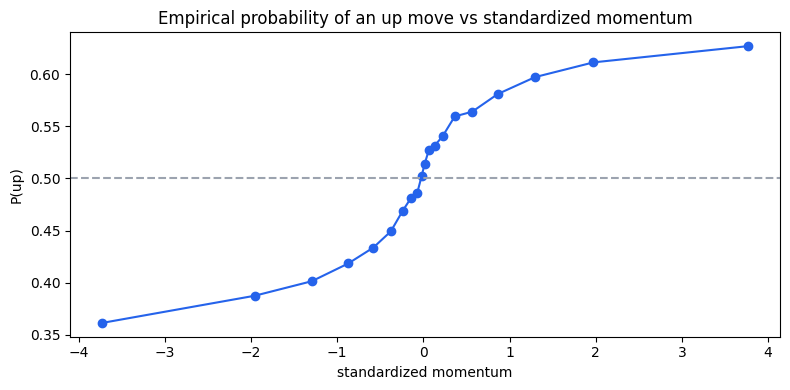

In [3]:
momentum_at_entry = momentum[entries]
bins = helper.quantile_bins(momentum_at_entry, momentum_at_entry, 20)
centres = [momentum_at_entry[bins == b].mean() for b in range(20)]
up_rate = [outcomes[bins == b].mean() for b in range(20)]

plt.figure(figsize=(8, 4))
plt.plot(centres, up_rate, "o-", color="#2563eb")
plt.axhline(0.5, ls="--", color="#9ca3af")
plt.title("Empirical probability of an up move vs standardized momentum")
plt.xlabel("standardized momentum"); plt.ylabel("P(up)")
plt.tight_layout(); plt.show()

## Part 2 - The volatility regimes

We split contracts into three volatility regimes by tercile (low, medium, high). The boundaries are
computed on the training window only, so no future information leaks in. The point of this split is
shown in Part 3: the momentum-to-probability relationship is not the same across regimes.

In [4]:
# Illustrate the regimes on the first 90-day training window.
training = slice(0, window_contracts)
training_entries = entries[training]
training_volatility = volatility[training_entries]
regime = helper.quantile_bins(training_volatility, training_volatility, volatility_regime_count)

low_edge, high_edge = np.quantile(training_volatility, [1/3, 2/3])
print(f"volatility tercile edges (annualized): {low_edge:.2f}, {high_edge:.2f}")
for r, name in enumerate(["low", "medium", "high"]):
    print(f"  {name:6s} volatility regime: {(regime == r).sum():,} contracts")

volatility tercile edges (annualized): 0.10, 0.16
  low    volatility regime: 86,400 contracts
  medium volatility regime: 86,400 contracts
  high   volatility regime: 86,400 contracts


## Part 3 - Calibrating one momentum curve per regime

Within each regime we build the curve `P(up)` vs momentum in four steps:
1. split momentum into 25 quantile bins;
2. take the empirical up-rate in each bin (fall back to 0.5 if a bin is too thin);
3. enforce a monotone (non-decreasing) curve by pooling out-of-order neighbours;
4. shrink toward 0.5, keeping 40% of each bin's edge, to avoid overfitting noise.

The plot shows the three calibrated curves. They differ: momentum is far more predictive in the
low-volatility regime than in the high-volatility one, which is exactly what a single curve misses.

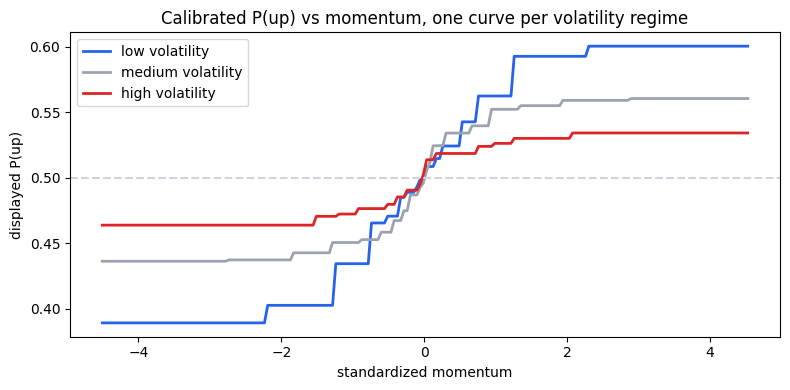

In [5]:
def calibrate_momentum_curve(training_momentum, training_outcomes):
    """Return (bin_edges, probability_per_bin): a monotone, shrunk P(up) curve vs momentum."""
    edges = np.quantile(training_momentum, np.linspace(0, 1, momentum_bin_count + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    bin_index = np.digitize(training_momentum, edges) - 1
    probability = np.array([
        training_outcomes[bin_index == b].mean() if (bin_index == b).sum() > minimum_samples_per_bin else 0.5
        for b in range(momentum_bin_count)])
    probability = helper.pool_adjacent_violators(probability, monotone_passes)
    return edges, 0.5 + calibration_shrinkage * (probability - 0.5)

def apply_curve(values, edges, probability_per_bin):
    index = np.clip(np.digitize(values, edges) - 1, 0, len(probability_per_bin) - 1)
    return probability_per_bin[index]

# Calibrate the three curves on the training window and plot them.
grid = np.linspace(np.percentile(momentum_at_entry, 1), np.percentile(momentum_at_entry, 99), 200)
plt.figure(figsize=(8, 4))
for r, (name, color) in enumerate(zip(["low", "medium", "high"], ["#2563eb", "#9ca3af", "#dc2626"])):
    mask = regime == r
    edges, probability_per_bin = calibrate_momentum_curve(momentum[training_entries][mask],
                                                          outcomes[training][mask])
    plt.plot(grid, apply_curve(grid, edges, probability_per_bin), color=color, lw=2,
             label=f"{name} volatility")
plt.axhline(0.5, ls="--", color="#d1d5db")
plt.title("Calibrated P(up) vs momentum, one curve per volatility regime")
plt.xlabel("standardized momentum"); plt.ylabel("displayed P(up)")
plt.legend(); plt.tight_layout(); plt.show()

## Part 4 - Rolling recalibration (walk-forward)

We do not calibrate once. Every week we recalibrate all three curves on the trailing 90 days, then
use them to price the next week, and repeat. This is walk-forward: every quote is built only from
past data. The model is 'live' only after the first full window (~90 days in), which we record as
`first_evaluation_second` and use as the start of every backtest below.

In [6]:
display_probability = np.full(features.number_of_seconds, 0.5)
first_evaluation_second = features.number_of_seconds

for start in range(window_contracts, len(entries), recompute_contracts):
    training_slice = slice(start - window_contracts, start)
    training_entries = entries[training_slice]
    training_regime = helper.quantile_bins(volatility[training_entries], volatility[training_entries],
                                           volatility_regime_count)
    curves = []
    for r in range(volatility_regime_count):
        mask = training_regime == r
        curves.append(calibrate_momentum_curve(momentum[training_entries][mask], outcomes[training_slice][mask])
                      if mask.sum() > minimum_samples_per_bin else None)

    segment_start = int(entries[start])
    next_start = min(len(entries), start + recompute_contracts)
    segment_stop = int(entries[next_start]) if next_start < len(entries) else features.number_of_seconds
    segment_regime = helper.quantile_bins(volatility[segment_start:segment_stop],
                                          volatility[training_entries], volatility_regime_count)
    segment_momentum = momentum[segment_start:segment_stop]
    segment_probability = np.full(segment_stop - segment_start, 0.5)
    for r, curve in enumerate(curves):
        if curve is None:
            continue
        in_regime = segment_regime == r
        if in_regime.any():
            segment_probability[in_regime] = apply_curve(segment_momentum[in_regime], *curve)
    display_probability[segment_start:segment_stop] = segment_probability
    first_evaluation_second = min(first_evaluation_second, segment_start)

print(f"model live from second {first_evaluation_second:,} (~{first_evaluation_second/86_400:.0f} days in)")
print(f"displayed P(up) range out-of-sample: "
      f"[{display_probability[first_evaluation_second:].min():.3f}, "
      f"{display_probability[first_evaluation_second:].max():.3f}]")

model live from second 7,776,605 (~90 days in)
displayed P(up) range out-of-sample: [0.386, 0.601]


## Part 5 - Pricing the odds

The displayed probability becomes decimal odds through `quote_odds`: it applies the house margin
(vig), never offers a side above its fair odds, and skews the odds toward the crowded side of the
book (inventory control). On a balanced book, a displayed 0.50 gives symmetric odds of about 1.75
(= 2 x (1 - vig)).

In [7]:
for probability in [0.50, 0.58, 0.42]:
    balanced = helper.quote_odds(probability, parameters.house_margin, 0.0, parameters)
    long_up = helper.quote_odds(probability, parameters.house_margin, 0.4, parameters)
    print(f"P(up)={probability:.2f}  balanced book -> up {balanced[0]:.3f} / down {balanced[1]:.3f}   "
          f"|  book long up -> up {long_up[0]:.3f} / down {long_up[1]:.3f}")

P(up)=0.50  balanced book -> up 1.750 / down 1.750   |  book long up -> up 1.139 / down 2.000
P(up)=0.58  balanced book -> up 1.509 / down 2.083   |  book long up -> up 1.066 / down 2.381
P(up)=0.42  balanced book -> up 2.083 / down 1.509   |  book long up -> up 1.239 / down 1.724


## Backtest with random (uninformed) flow

The realistic case: most flow is uninformed. We replay a balanced noise pool through the live book
over several out-of-sample windows and check the house edge holds near the vig, with a steady PnL and
a controlled book.

In [8]:
window_length = 150_000

def run_windows(make_flow, number_of_windows, seed_base=100):
    rows = []
    for w in range(number_of_windows):
        start = first_evaluation_second + w * window_length
        if start + window_length + parameters.horizon_seconds >= features.number_of_seconds:
            break
        result = helper.simulate(display_probability, parameters.house_margin, features,
                                 make_flow(), start, window_length, parameters, seed=seed_base + w)
        rows.append(result)
    return rows

noise_runs = run_windows(lambda: {"pool": helper.noise_pool()}, number_of_windows=6)
edges = np.array([r.house_edge for r in noise_runs])
total_pnl = sum(r.house_pnl for r in noise_runs)
total_volume = sum(r.total_volume for r in noise_runs)
print(f"noise pool over {len(noise_runs)} windows:")
print(f"  house edge per window: mean {edges.mean():+.3%}, std {edges.std():.3%}, "
      f"min {edges.min():+.3%}, max {edges.max():+.3%}")
print(f"  aggregate house edge: {total_pnl/total_volume:+.3%}")
print(f"  max |net delta| hit: ${max(r.max_absolute_net_delta for r in noise_runs):,.0f} "
      f"(cap ${parameters.maximum_net_delta:,.0f})")

noise pool over 6 windows:
  house edge per window: mean +12.878%, std 0.190%, min +12.661%, max +13.236%
  aggregate house edge: +12.878%
  max |net delta| hit: $477 (cap $20,000)


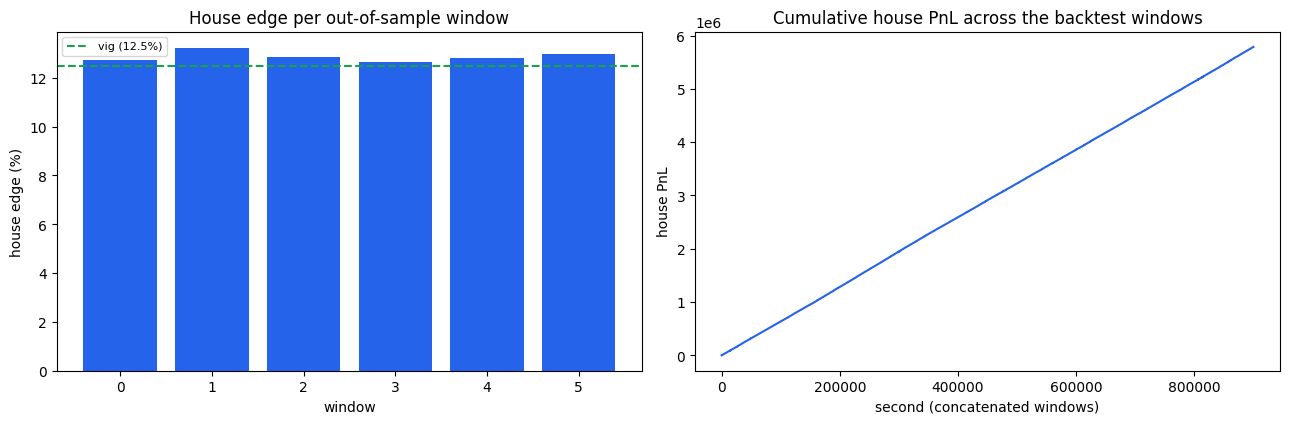

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(len(edges)), edges * 100, color="#2563eb")
axes[0].axhline(parameters.house_margin * 100, ls="--", color="#16a34a", label=f"vig ({parameters.house_margin:.1%})")
axes[0].set_title("House edge per out-of-sample window"); axes[0].set_xlabel("window")
axes[0].set_ylabel("house edge (%)"); axes[0].legend(fontsize=8)

running = []
offset = 0.0
for r in noise_runs:
    running.append(r.pnl_series + offset)
    offset += r.house_pnl
axes[1].plot(np.concatenate(running), color="#2563eb")
axes[1].set_title("Cumulative house PnL across the backtest windows")
axes[1].set_xlabel("second (concatenated windows)"); axes[1].set_ylabel("house PnL")
plt.tight_layout(); plt.show()

**Public technical strategies are not profitable against the model.** Trend-following and
mean-reversion are the two most common public strategies. Because the model already prices momentum,
both lose: trend-following a bit less than the vig, mean-reversion more (it fights the very momentum
the model prices). Either way the house keeps a positive edge on them.

In [10]:
for name, factory in [("trend-following", lambda: {"bettor": helper.momentum_follower(features)}),
                      ("mean-reversion", lambda: {"bettor": helper.mean_reversion_fader(features)})]:
    runs = run_windows(factory, number_of_windows=4, seed_base=300)
    pnl = sum(r.per_bettor["bettor"].pnl for r in runs)
    stake = sum(r.per_bettor["bettor"].stake for r in runs)
    print(f"{name:16s} bettor edge = {pnl/stake:+.3%}  (house keeps {-pnl/stake:+.3%})")

trend-following  bettor edge = -8.467%  (house keeps +8.467%)


mean-reversion   bettor edge = -19.105%  (house keeps +19.105%)


## Smart flow: why it should not be a problem, and where it can hurt

Informed flow is almost impossible to predict, so instead we argue why it is contained, and we bound
the worst case.

**Why it is mostly fine.**
1. The model already prices the main public signal (momentum, per volatility regime), so trend and
   mean-reversion players just pay the vig (shown above).
2. The book skews the odds toward the crowded side and hard-caps the net delta, so no bettor can load
   one side without moving the price against themselves. Any leak is small and bounded.

**The residual threat: a regime-aware attacker** who has calibrated the same momentum-by-volatility
table we have, but keeps the full (un-shrunk) edge. Below we let it bet inside a noise pool, then
sweep its size to show its edge is capacity-limited: as it grows it moves the book against itself.

               volume share  attacker edge
attacker size                             
0.5                     4.2           3.14
1.0                     7.3           2.98
3.0                    16.5           1.92
6.0                    27.3           1.14
10.0                   38.8           0.18
20.0                   58.5           0.49


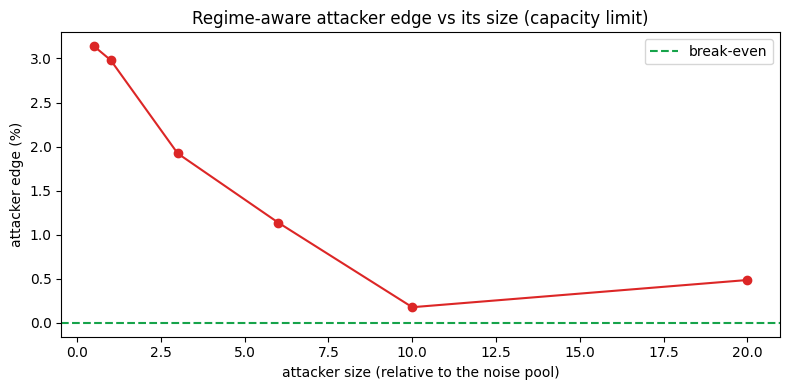

In [11]:
regime_signal = helper.regime_conditional_probability(features, parameters)

rows = []
for size in [0.5, 1, 3, 6, 10, 20]:
    attacker_pnl = attacker_stake = pool_volume = 0.0
    for w in range(3):
        start = first_evaluation_second + w * window_length
        flow = {"pool": helper.noise_pool(),
                "attacker": helper.regime_aware_bettor(regime_signal, size=size)}
        result = helper.simulate(display_probability, parameters.house_margin, features, flow,
                                 start, window_length, parameters, seed=500 + w)
        attacker = result.per_bettor["attacker"]
        attacker_pnl += attacker.pnl; attacker_stake += attacker.stake
        pool_volume += result.per_bettor["pool"].stake
    rows.append({"attacker size": size,
                 "volume share": attacker_stake / (attacker_stake + pool_volume),
                 "attacker edge": attacker_pnl / attacker_stake if attacker_stake else 0.0})

capacity = pd.DataFrame(rows).set_index("attacker size")
print(capacity.assign(**{"volume share": (capacity["volume share"] * 100).round(1),
                         "attacker edge": (capacity["attacker edge"] * 100).round(2)}).to_string())

plt.figure(figsize=(8, 4))
plt.plot(capacity.index, capacity["attacker edge"] * 100, "o-", color="#dc2626")
plt.axhline(0, ls="--", color="#16a34a", label="break-even")
plt.title("Regime-aware attacker edge vs its size (capacity limit)")
plt.xlabel("attacker size (relative to the noise pool)"); plt.ylabel("attacker edge (%)")
plt.legend(); plt.tight_layout(); plt.show()

In [12]:
# A latency attacker using the faster Binance feed that leads the settlement oracle.
fast_feed = helper.load_fast_feed(expected_length=features.number_of_seconds)
runs = run_windows(lambda: {"pool": helper.noise_pool(),
                            "attacker": helper.lead_lag_bettor(features, fast_feed.log_price)},
                   number_of_windows=3, seed_base=700)
pnl = sum(r.per_bettor["attacker"].pnl for r in runs)
stake = sum(r.per_bettor["attacker"].stake for r in runs)
print(f"latency (lead-lag) attacker edge at the {parameters.horizon_seconds}s horizon = {pnl/stake:+.3%}")

latency (lead-lag) attacker edge at the 30s horizon = -16.574%


**Where smart flow can still hurt.**
- **Latency / lead-lag.** A bettor on a faster feed (for example Binance leading the settlement
  oracle). At our 30-second horizon this loses (the lead washes out before settlement), but at a
  shorter horizon, or with true low-latency execution, it would become the real threat. The model
  does not use the fast feed.
- **Finer structure than three regimes.** The regime-aware attacker keeps a small positive edge on a
  tiny share of volume; it comes from volatility structure finer than three terciles, plus the edge
  we deliberately shrink away. It is capacity-limited (above).
- **Regime shifts.** If the volatility/momentum relationship changes faster than the 90-day window
  adapts.
- **Genuine private information** (news, order flow we cannot see). Unpriceable, but still bounded by
  the net-delta cap.

## Model card

- **Prices:** P(up) from standardized momentum, calibrated per volatility regime (3 terciles),
  monotone and shrunk (keep 40% of the edge), recalibrated on a rolling 90-day window every week.
- **Charges:** the house margin (vig), with inventory skew and a hard net-delta cap.
- **Strengths:** holds the vig on uninformed and public flow; prices the volatility-regime mispricing
  that a single momentum curve leaves open; keeps competitive, sane odds (so it keeps volume).
- **Residual risks:** latency/lead-lag at short horizons, structure finer than three regimes, regime
  shifts, and private information; all small and bounded by the book controls.